In [1]:
import xradar as xd
import xarray as xr
import fsspec
from datetime import datetime
import numpy as np
from pyproj import CRS, Transformer
%matplotlib widget
from dask.distributed import Client, LocalCluster

In [2]:

# Create the local cluster with custom dashboard address
cluster = LocalCluster(
    dashboard_address=':8087'  # <-- Set dashboard port here
)
client = Client(cluster)

In [3]:
def create_query(date, band='C01'):
    """
    Creates a query for listing GOES16 files stored in AWS bucket
    :param date: date to be queried. e.g datetime(2021, 10, 3, 12). Datetime python object
    :param band: Goes16 band to be queried e.g. C01
    :return: string with a
    """
    prefix = f'ABI-L1b-RadF/{date:%Y}/{date.timetuple().tm_yday:03d}/{date:%H}/OR_ABI-L1b-RadF-M6{band}_G19_s' \
             f'{date:%Y}{date.timetuple().tm_yday:03d}*'
    return prefix

def download_s3file(s3_path: str)-> str:
    return fsspec.open_local(
            f"simplecache::s3://{s3_path}",
            s3={"anon": True},
            filecache={"cache_storage": "."},
        )

def get_geocoords(ds):
    """
    Converts Cartesian coordinates (x, y, z) in a radar dataset to geographic
    coordinates (longitude, latitude, altitude) using CRS transformation.

    Parameters
    ----------
    ds : xarray.Dataset
        Radar dataset with Cartesian coordinates.

    Returns
    -------
    xarray.Dataset
        Dataset with added 'lon', 'lat', and 'alt' coordinates and their attributes.
    """
    from pyproj import CRS, Transformer

    # Convert the dataset to georeferenced coordinates
    ds = ds.xradar.georeference()
    # Define source and target coordinate reference systems (CRS)
    src_crs = ds.xradar.get_crs()
    trg_crs = CRS.from_user_input(4326)  # EPSG:4326 (WGS 84)
    # Create a transformer for coordinate conversion
    transformer = Transformer.from_crs(src_crs, trg_crs)
    # Transform x, y, z coordinates to latitude, longitude, and altitude
    trg_y, trg_x, trg_z = transformer.transform(ds.x, ds.y, ds.z)
    # Assign new coordinates with appropriate attributes
    ds = ds.assign_coords(
        {
            "lon": (ds.x.dims, trg_x, xd.model.get_longitude_attrs()),
            "lat": (ds.y.dims, trg_y, xd.model.get_latitude_attrs()),
            "alt": (ds.z.dims, trg_z, xd.model.get_altitude_attrs()),
        }
    )
    return ds
    

def calc_latlon(ds):
    x = ds.x.values
    y = ds.y.values
    goes_imager_projection = ds.goes_imager_projection

    X, Y = np.meshgrid(x, y)

    r_eq = goes_imager_projection.attrs["semi_major_axis"]
    r_pol = goes_imager_projection.attrs["semi_minor_axis"]
    l_0 = goes_imager_projection.attrs["longitude_of_projection_origin"] * (np.pi / 180)
    h_sat = goes_imager_projection.attrs["perspective_point_height"]
    H = r_eq + h_sat

    a = np.sin(X) ** 2 + (np.cos(X) ** 2 * (np.cos(Y) ** 2 + (r_eq ** 2 / r_pol ** 2) * np.sin(Y) ** 2))
    b = -2 * H * np.cos(X) * np.cos(Y)
    c = H ** 2 - r_eq ** 2

    r_s = (-b - np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)

    s_x = r_s * np.cos(X) * np.cos(Y)
    s_y = -r_s * np.sin(X)
    s_z = r_s * np.cos(X) * np.sin(Y)

    lat = np.arctan((r_eq ** 2 / r_pol ** 2) * (s_z / np.sqrt((H - s_x) ** 2 + s_y ** 2))) * (180 / np.pi)
    lon = (l_0 - np.arctan(s_y / (H - s_x))) * (180 / np.pi)

    # Keep full 2D lat/lon as coordinates
    ds = ds.assign_coords({
        "latitude": (("y", "x"), lat),
        "longitude": (("y", "x"), lon)
    })

    return ds



def get_xy_from_latlon(ds, lats, lons):
    lat1, lat2 = lats
    lon1, lon2 = lons

    lat = ds.latitude.values
    lon = ds.longitude.values

    x = ds.x.values
    y = ds.y.values

    X, Y = np.meshgrid(x, y)

    mask = (lat >= lat1) & (lat <= lat2) & (lon >= lon1) & (lon <= lon2)

    if not np.any(mask):
        raise ValueError("No matching lat/lon values found.")

    x_filtered = X[mask]
    y_filtered = Y[mask]

    return ((np.nanmin(x_filtered), np.nanmax(x_filtered)),
            (np.nanmin(y_filtered), np.nanmax(y_filtered)))



def normalization(da, vmin, vmax, gamma):
    norm = (da - vmin) / (vmax - vmin)
    norm = np.clip(norm, 0, 1)
    return np.power(norm, gamma)


def rad2tb(ds):
        """
        https://www.star.nesdis.noaa.gov/goesr/docs/ATBD/Imagery.pdf pag 22
        """
        fk1 = ds['planck_fk1']
        fk2 = ds['planck_fk2']
        bc1 = ds['planck_bc1']
        bc2 = ds['planck_bc2']
        bt = ((fk2 / (np.log((fk1 / ds.Rad) + 1))) - bc1) / bc2
        return bt

In [4]:
dt = datetime(2025, 4, 2, 13, 10, 4)  # Match your original timestamp
query = create_query(dt, band="C13")
query

'ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s2025092*'

In [5]:
fs = fsspec.filesystem("s3", anon=True)
year = 2025
car_files =  ['s3://' + f for f in 
              sorted(fs.glob(f"s3-radaresideam/l2_data/{year}/04/02/Carimagua/CAR*"))
             ]

In [6]:
dt_car = xd.io.open_iris_datatree(
        download_s3file(car_files[1553]),
        chunks={"azimuth": 360, "range": 497}
    ).xradar.map_over_sweeps(get_geocoords)

In [7]:
goes_files =  ['s3://' + f for f in
              # sorted(fs.glob(f"s3://noaa-goes19/ABI-L1b-RadF/2025/092/13/*"))
              sorted(fs.glob(f"s3://noaa-goes19/{query}"))
             ]


In [8]:
radar = dt_car["sweep_0"].ds

In [9]:
ds_goes = xr.open_dataset(
    download_s3file(goes_files[1]), 
    chunks={'x': 512, 'y': 512},
)

ds_goes = calc_latlon(ds_goes)

lat_bounds = (1.8, 7.3)
lon_bounds = (-74.1, -68.6)

(x_min, x_max), (y_min, y_max) = get_xy_from_latlon(ds_goes, lat_bounds, lon_bounds)

# Crop GOES to this extent in native projection
ds_goes_crop = ds_goes.sel(
    x=slice(x_min, x_max),
    y=slice(y_max, y_min)
)


### overlay using cartopy

In [10]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Subset radar to GOES extent
# lat_bounds = (ds_goes_crop.latitude.min().item(), ds_goes_crop.latitude.max().item())
# lon_bounds = (ds_goes_crop.longitude.min().item(), ds_goes_crop.longitude.max().item())

# radar_sub = radar.where(
#     (radar.lat >= lat_bounds[0]) & (radar.lat <= lat_bounds[1]) &
#     (radar.lon >= lon_bounds[0]) & (radar.lon <= lon_bounds[1]),
#     drop=True
# )

# # Set up map
# proj = ccrs.PlateCarree()
# fig = plt.figure(figsize=(10, 8))
# ax = plt.axes(projection=proj)

# # Add map features
# ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.STATES, edgecolor='gray')

# # ✅ 1. Plot radar first (background)
# im2 = ax.pcolormesh(
#     radar.lon, radar.lat, radar.DBZH,
#     transform=ccrs.PlateCarree(), cmap='turbo', shading='auto'
# )

# # ✅ 2. Plot GOES second (foreground) with transparency
# im1 = ax.pcolormesh(
#     ds_goes_crop.longitude, ds_goes_crop.latitude, ds_goes_crop.Rad,
#     transform=ccrs.PlateCarree(), cmap="Greys", shading='auto', alpha=0.5
# )

# # Set extent
# ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], crs=proj)

# # Colorbars
# plt.colorbar(im2, ax=ax, orientation='vertical', label="Radar Reflectivity (dBZ)")
# plt.colorbar(im1, ax=ax, orientation='vertical', label="GOES Radiance", shrink=0.75)

# plt.title("Radar (Background) + GOES (Foreground with Transparency)")
# plt.show()


### vertical bar using matplotlib

0

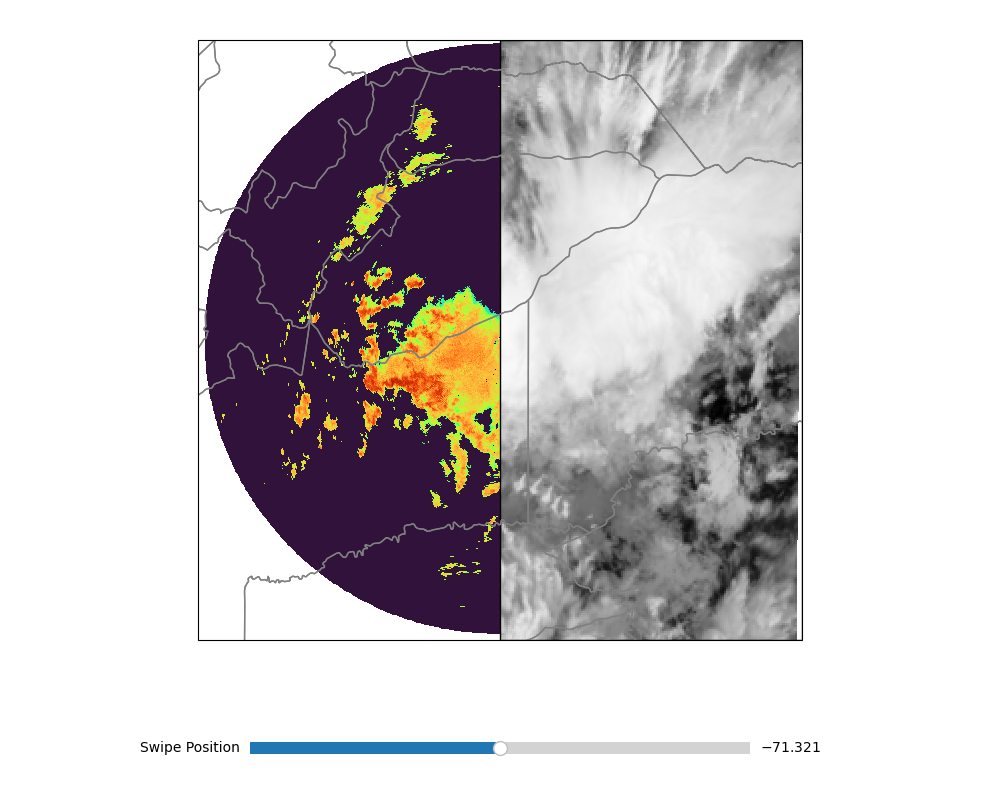

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Slider
from matplotlib.path import Path
from matplotlib.transforms import Bbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set up map
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes([0.05, 0.2, 0.9, 0.75], projection=proj)

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='gray')

# Extent
lat_bounds = (ds_goes_crop.latitude.min().item(), ds_goes_crop.latitude.max().item())
lon_bounds = (ds_goes_crop.longitude.min().item(), ds_goes_crop.longitude.max().item())
ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], crs=proj)

# Plot radar fully
im_radar = ax.pcolormesh(
    radar.lon, radar.lat, radar.DBZH,
    transform=ccrs.PlateCarree(), cmap='turbo', shading='auto'
)

# Plot GOES fully, but we'll clip it
im_goes = ax.pcolormesh(
    ds_goes_crop.longitude, ds_goes_crop.latitude, ds_goes_crop.Rad,
    transform=ccrs.PlateCarree(), cmap='Greys', shading='auto'
)

# Create a clip path that is a rectangle from mid_lon to the right
mid_lon = (lon_bounds[0] + lon_bounds[1]) / 2

def make_clip_patch(x_start):
    # Create rectangle Path in lat/lon space
    verts = [
        (x_start, lat_bounds[0]),
        (lon_bounds[1], lat_bounds[0]),
        (lon_bounds[1], lat_bounds[1]),
        (x_start, lat_bounds[1]),
        (x_start, lat_bounds[0])
    ]
    codes = [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    clip_path = Path(verts, codes)
    patch = mpatches.PathPatch(clip_path, transform=proj, facecolor='none')
    return patch

# Initial clip
clip_patch = make_clip_patch(mid_lon)
ax.add_patch(clip_patch)
im_goes.set_clip_path(clip_patch)

# Slider
ax_slider = plt.axes([0.25, 0.05, 0.5, 0.03])
slider = Slider(ax_slider, "Swipe Position", lon_bounds[0], lon_bounds[1], valinit=mid_lon)

def update(val):
    new_patch = make_clip_patch(val)
    im_goes.set_clip_path(new_patch)
    ax.patches[-1] = new_patch  # Replace last patch with new one
    fig.canvas.draw_idle()

slider.on_changed(update)

# plt.show()


### using HVPLOT, panel and datashader

In [12]:
ds_goes_crop = ds_goes_crop.chunk({'x': 512, 'y': 512}).persist()

In [13]:
import numpy as np
import xarray as xr
import holoviews as hv
import hvplot.xarray
import panel as pn

hv.extension('bokeh')
pn.extension()

# -- Set longitude bounds from your GOES data
lon_min = float(ds_goes_crop.longitude.min())
lon_max = float(ds_goes_crop.longitude.max())

# -- Function to mask GOES based on swipe position

In [ ]:
def create_masked_goes(threshold_lon):
    # Only keep pixels where longitude >= swipe line
    mask = ds_goes_crop.longitude >= threshold_lon
    masked_goes = ds_goes_crop.Rad.where(mask)
    return masked_goes.hvplot.quadmesh(
    x='longitude', y='latitude',
    cmap='Greys', clim=(0, None), alpha=1.0,
    title="GOES (Right side only)",
    rasterize=True  # <--- KEY
)

# -- Static radar background
radar_plot = radar.DBZH.unify_chunks().hvplot.quadmesh(
    x='lon', y='lat', cmap='ChaseSpectral',
    clim=(0, 70), alpha=1.0, title="Radar (Full)",
        # rasterize=True  # <--- KEY
)

# -- Slider that controls the longitude swipe
swipe_slider = pn.widgets.FloatSlider(
    name="Swipe Longitude", start=lon_min, end=lon_max,
    value=(lon_min + lon_max) / 2, step=0.1
)

# -- Function to generate overlay
def swipe_overlay(threshold_lon):
    masked_goes = create_masked_goes(threshold_lon)
    return radar_plot * masked_goes

# -- Bind the function to the slider
bound_overlay = pn.bind(swipe_overlay, swipe_slider)

# -- Layout
layout = pn.Column(
    swipe_slider,
    pn.pane.HoloViews(bound_overlay(), width=700, height=600)
)

layout.servable()  # If running as a Panel app
